In [3]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [4]:
# 1. Load dataset

DATASET_FILE = "../dataset/supplier_quotes_synthetic_realistic.csv"

df = pd.read_csv(DATASET_FILE)

print("\nSUPPLIER QUOTE ML TRAINING")
print("=" * 60)

print(f"Dataset loaded: {DATASET_FILE}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")


SUPPLIER QUOTE ML TRAINING
Dataset loaded: ../dataset/supplier_quotes_synthetic_realistic.csv
Rows: 1000
Columns: 12


In [5]:
# 2. Select features and target

# These match your real app form fields plus region
feature_columns = [
    "materialName",
    "unitPrice",
    "quantity",
    "deliveryDays",
    "region"
]

target_column = "riskStatus"

X = df[feature_columns]
y = df[target_column]

print("\nFeatures used for training:")
print(feature_columns)

print("\nTarget column:")
print(target_column)

print("\nTarget distribution:")
print(y.value_counts())
print((y.value_counts(normalize=True) * 100).round(2))


Features used for training:
['materialName', 'unitPrice', 'quantity', 'deliveryDays', 'region']

Target column:
riskStatus

Target distribution:
riskStatus
Normal     750
Anomaly    250
Name: count, dtype: int64
riskStatus
Normal     75.0
Anomaly    25.0
Name: proportion, dtype: float64


In [6]:
# 3. Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTRAIN/TEST SPLIT")
print("-" * 60)
print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())



TRAIN/TEST SPLIT
------------------------------------------------------------
Training rows: 800
Testing rows: 200

Training target distribution:
riskStatus
Normal     600
Anomaly    200
Name: count, dtype: int64

Testing target distribution:
riskStatus
Normal     150
Anomaly     50
Name: count, dtype: int64


In [7]:
# 4. Preprocessing


categorical_features = [
    "materialName",
    "region"
]

numeric_features = [
    "unitPrice",
    "quantity",
    "deliveryDays"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", StandardScaler(), numeric_features)
    ]
)

In [8]:
# 5. Build ML model


model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    class_weight="balanced"
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [9]:
# 6. Train model


pipeline.fit(X_train, y_train)

print("\nModel training completed.")



Model training completed.


In [10]:
# 7. Evaluate model


y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nMODEL EVALUATION")
print("-" * 60)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred))



MODEL EVALUATION
------------------------------------------------------------
Accuracy: 0.9300

Classification report:
              precision    recall  f1-score   support

     Anomaly       0.97      0.74      0.84        50
      Normal       0.92      0.99      0.96       150

    accuracy                           0.93       200
   macro avg       0.95      0.87      0.90       200
weighted avg       0.93      0.93      0.93       200



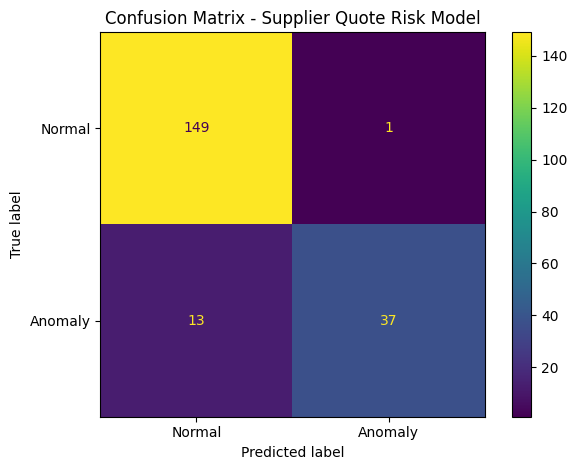


Confusion matrix saved as:
model_confusion_matrix.png


In [ ]:
# 8. Confusion matrix


cm = confusion_matrix(y_test, y_pred, labels=["Normal", "Anomaly"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"]
)

disp.plot()
plt.title("Confusion Matrix - Supplier Quote Risk Model")
plt.tight_layout()
plt.savefig("../ml-model/model_confusion_matrix.png", dpi=300)
plt.show()

print("\nConfusion matrix saved as:")
print("model_confusion_matrix.png")


In [12]:
# 9. Test model with sample quotes


sample_quotes = pd.DataFrame([
    {
        "materialName": "Steel",
        "unitPrice": 980,
        "quantity": 100,
        "deliveryDays": 6,
        "region": "Ontario"
    },
    {
        "materialName": "Steel",
        "unitPrice": 1450,
        "quantity": 100,
        "deliveryDays": 8,
        "region": "Ontario"
    },
    {
        "materialName": "Concrete",
        "unitPrice": 180,
        "quantity": 300,
        "deliveryDays": 5,
        "region": "Quebec"
    },
    {
        "materialName": "Copper",
        "unitPrice": 13000,
        "quantity": 50,
        "deliveryDays": 10,
        "region": "New York"
    },
    {
        "materialName": "Wood",
        "unitPrice": 75,
        "quantity": 500,
        "deliveryDays": 55,
        "region": "Ontario"
    }
])

sample_predictions = pipeline.predict(sample_quotes)
sample_probabilities = pipeline.predict_proba(sample_quotes)

print("\nSAMPLE PREDICTIONS")
print("-" * 60)

for i, quote in sample_quotes.iterrows():
    prediction = sample_predictions[i]
    probability = max(sample_probabilities[i])

    print(f"\nQuote {i + 1}:")
    print(quote.to_dict())
    print(f"Predicted riskStatus: {prediction}")
    print(f"Prediction confidence: {probability:.2f}")


SAMPLE PREDICTIONS
------------------------------------------------------------

Quote 1:
{'materialName': 'Steel', 'unitPrice': 980, 'quantity': 100, 'deliveryDays': 6, 'region': 'Ontario'}
Predicted riskStatus: Normal
Prediction confidence: 0.90

Quote 2:
{'materialName': 'Steel', 'unitPrice': 1450, 'quantity': 100, 'deliveryDays': 8, 'region': 'Ontario'}
Predicted riskStatus: Normal
Prediction confidence: 0.58

Quote 3:
{'materialName': 'Concrete', 'unitPrice': 180, 'quantity': 300, 'deliveryDays': 5, 'region': 'Quebec'}
Predicted riskStatus: Normal
Prediction confidence: 0.87

Quote 4:
{'materialName': 'Copper', 'unitPrice': 13000, 'quantity': 50, 'deliveryDays': 10, 'region': 'New York'}
Predicted riskStatus: Normal
Prediction confidence: 0.53

Quote 5:
{'materialName': 'Wood', 'unitPrice': 75, 'quantity': 500, 'deliveryDays': 55, 'region': 'Ontario'}
Predicted riskStatus: Anomaly
Prediction confidence: 0.85


In [ ]:
# 10. Save trained model


MODEL_FILE = "../ml-model/supplier_quote_risk_model.pkl"

joblib.dump(pipeline, MODEL_FILE)

print("\nMODEL SAVED")
print("-" * 60)
print(f"Trained model saved as: {MODEL_FILE}")

print("\nThis model can later be loaded inside Lambda to predict:")
print("riskStatus = Normal or Anomaly")


MODEL SAVED
------------------------------------------------------------
Trained model saved as: supplier_quote_risk_model.pkl

This model can later be loaded inside Lambda to predict:
riskStatus = Normal or Anomaly
